In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import os
import warnings
import json  # <-- ADD THIS LINE
warnings.filterwarnings('ignore')

In [2]:
data_dir="bike_sharing_data"
os.makedirs(data_dir, exist_ok=True)

print("Downloading Bike Sharing Demand dataset...\n")

files = {
    'train.csv': 'https://raw.githubusercontent.com/dataoptimal/datasets/master/Kaggle_Bike_Sharing_Demand/train.csv',
}

for filename, url in files.items():
    try:
        print(f"Downloading {filename}...")
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        filepath=f'{data_dir}/{filename}'
        with open(filepath, 'wb') as f:
            f.write(response.content)

        size_kb = len(response.content) / 1024
        print(f"✓ {filename} ({size_kb:.1f} KB)\n")
    except Exception as e:
        print(f"✗ Failed to download {filename}: {e}\n")

print(f"✓ Data downloaded to '{data_dir}/' directory")




✗ Failed to download train.csv: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/dataoptimal/datasets/master/Kaggle_Bike_Sharing_Demand/train.csv

✓ Data downloaded to 'bike_sharing_data/' directory


In [3]:
print(" ")
print("Selecting Features...")

df=pd.read_csv('bike_sharing_data/train.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day

df['zone_density'] = df['humidity']

feature_cols=['hour', 'day', 'temp', 'weather', 'zone_density']
target_col='count'

print(f"Dataset shape: {df.shape}")
print(f"Features selected: {feature_cols}")
print(f"Target variable: {target_col} (hourly demand in bikes)")
print(f"\nFeature Statistics:")
print(df[feature_cols + [target_col]].describe())

X=df[feature_cols].values
y=df[target_col].values

print(f"\n✓ Step 2 Complete: Features selected ({len(feature_cols)} features)")

print("\n[STEP 3] Train-Test Split...\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {X_train.shape[0]} (80%)")
print(f"Testing samples: {X_test.shape[0]} (20%)")
print(f"Training demand mean: {y_train.mean():.2f} bikes/hour")
print(f"Testing demand mean: {y_test.mean():.2f} bikes/hour")

print(f"\n✓ Step 3 Complete: Data split into train ({X_train.shape[0]}) and test ({X_test.shape[0]})")

print("\n[STEP 4] Training Regression Models...\n")


print("Training Linear Regression...")
lr_model=LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr=lr_model.predict(X_test)
mae_lr=mean_absolute_error(y_test, y_pred_lr)
rmse_lr=np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr=lr_model.score(X_test, y_test)
print(" Linear Regression trained")

print("Training Random Forest Regressor")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = rf_model.score(X_test, y_test)
print("Random Forest trained")

print("\nBoth models trained successfully")


print("step 5: Model Performance - MAE and RMSE\n")

print("="*80)
print("LINEAR REGRESSION")
print("="*80)
print(f"  MAE  (Mean Absolute Error):        {mae_lr:.2f} bikes/hour")
print(f"  RMSE (Root Mean Squared Error):    {rmse_lr:.2f} bikes/hour")
print(f"  R² Score:                          {r2_lr:.4f}")

print("\n" + "="*80)
print("RANDOM FOREST REGRESSOR")
print("="*80)
print(f"  MAE  (Mean Absolute Error):        {mae_rf:.2f} bikes/hour")
print(f"  RMSE (Root Mean Squared Error):    {rmse_rf:.2f} bikes/hour")
print(f"  R² Score:                          {r2_rf:.4f}")


best_model_name = 'Random Forest' if rmse_rf < rmse_lr else 'Linear Regression'
best_model = rf_model if rmse_rf < rmse_lr else lr_model
best_mae = min(mae_lr, mae_rf)
best_rmse = min(rmse_lr, rmse_rf)

print("\n" + "="*80)
print("BEST MODEL: {best_model_name}")
print("  MAE:  {best_mae:.2f} bikes/hour")
print("  RMSE: {best_rmse:.2f} bikes/hour")
print("="*80)

print("Step 5 Complete: Metrics reported")


print("\n[STEP 6] Exporting Predictions for Fleet Selector Module\n")


def predict_demand_by_hour(hour, model=best_model, avg_temp=20, weather=2, avg_density=50):
    day = 15  # Middle of month as default
    sample = np.array([[hour, day, avg_temp, weather, avg_density]])
    return model.predict(sample)[0]


print("Generating hourly demand forecast for fleet planning...\n")

hourly_forecast = {}
total_daily_demand = 0

print("Hour | Predicted Demand | Zone Assignment")
print("-" * 45)

for hour in range(24):
    predicted_demand = predict_demand_by_hour(hour)
    hourly_forecast[hour] = {
        'demand': float(predicted_demand),
        'light_drones_needed': max(1, int(np.ceil(predicted_demand / 20))),
        'heavy_drones_needed': max(0, int(np.ceil((predicted_demand - 100) / 30))),
    }
    total_daily_demand += predicted_demand

    demand_level = "HIGH" if predicted_demand > 200 else "MEDIUM" if predicted_demand > 100 else "LOW"
    print(f"{hour:2d}   | {predicted_demand:6.0f} bikes       | {demand_level}")

print("-" * 45)
print(f"Total daily demand (forecast): {total_daily_demand:.0f} bikes")
print(f"Average hourly demand: {total_daily_demand/24:.0f} bikes/hour")


print("\n\nExporting demand forecast to file...\n")

output_dir = "demand_forecast_output"
os.makedirs(output_dir, exist_ok=True)

with open(f'{output_dir}/hourly_demand_forecast.json', 'w') as f:
    json.dump(hourly_forecast, f, indent=2)

forecast_df = pd.DataFrame([
    {
        'hour': hour,
        'predicted_demand': forecast['demand'],
        'light_drones_needed': forecast['light_drones_needed'],
        'heavy_drones_needed': forecast['heavy_drones_needed']
    }
    for hour, forecast in hourly_forecast.items()
])

forecast_df.to_csv(f'{output_dir}/hourly_demand_forecast.csv', index=False)

metrics = {
    'best_model': best_model_name,
    'linear_regression': {
        'mae': float(mae_lr),
        'rmse': float(rmse_lr),
        'r2': float(r2_lr)
    },
    'random_forest': {
        'mae': float(mae_rf),
        'rmse': float(rmse_rf),
        'r2': float(r2_rf)
    },
    'total_daily_demand_forecast': float(total_daily_demand),
    'average_hourly_demand': float(total_daily_demand / 24)
}

with open(f'{output_dir}/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✓ Exported hourly demand forecast:")
print(f"  - {output_dir}/hourly_demand_forecast.json")
print(f"  - {output_dir}/hourly_demand_forecast.csv")
print(f"  - {output_dir}/model_metrics.json")


 
Selecting Features...
Dataset shape: (10886, 15)
Features selected: ['hour', 'day', 'temp', 'weather', 'zone_density']
Target variable: count (hourly demand in bikes)

Feature Statistics:
               hour           day         temp       weather  zone_density  \
count  10886.000000  10886.000000  10886.00000  10886.000000  10886.000000   
mean      11.541613      9.992559     20.23086      1.418427     61.886460   
std        6.915838      5.476608      7.79159      0.633839     19.245033   
min        0.000000      1.000000      0.82000      1.000000      0.000000   
25%        6.000000      5.000000     13.94000      1.000000     47.000000   
50%       12.000000     10.000000     20.50000      1.000000     62.000000   
75%       18.000000     15.000000     26.24000      2.000000     77.000000   
max       23.000000     19.000000     41.00000      4.000000    100.000000   

              count  
count  10886.000000  
mean     191.574132  
std      181.144454  
min        1.000000

Step 6 Complete: Predictions exported for Fleet Selector module


Generating visualizations...



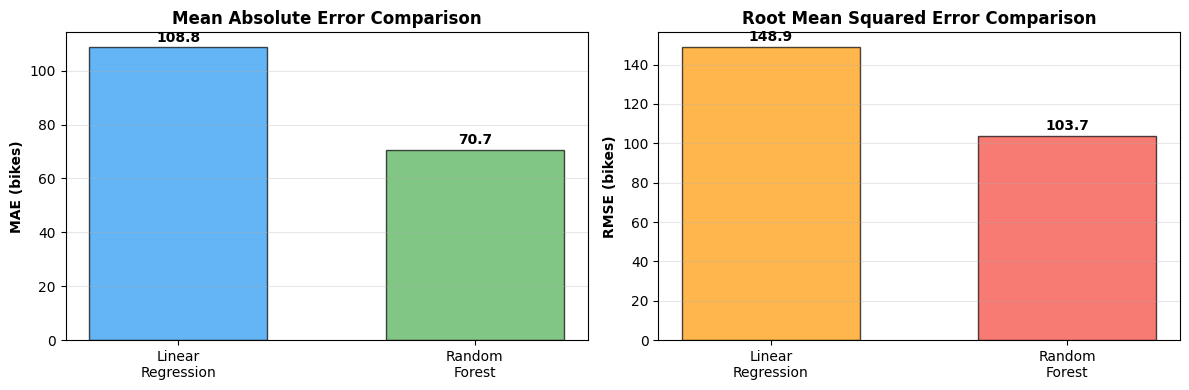

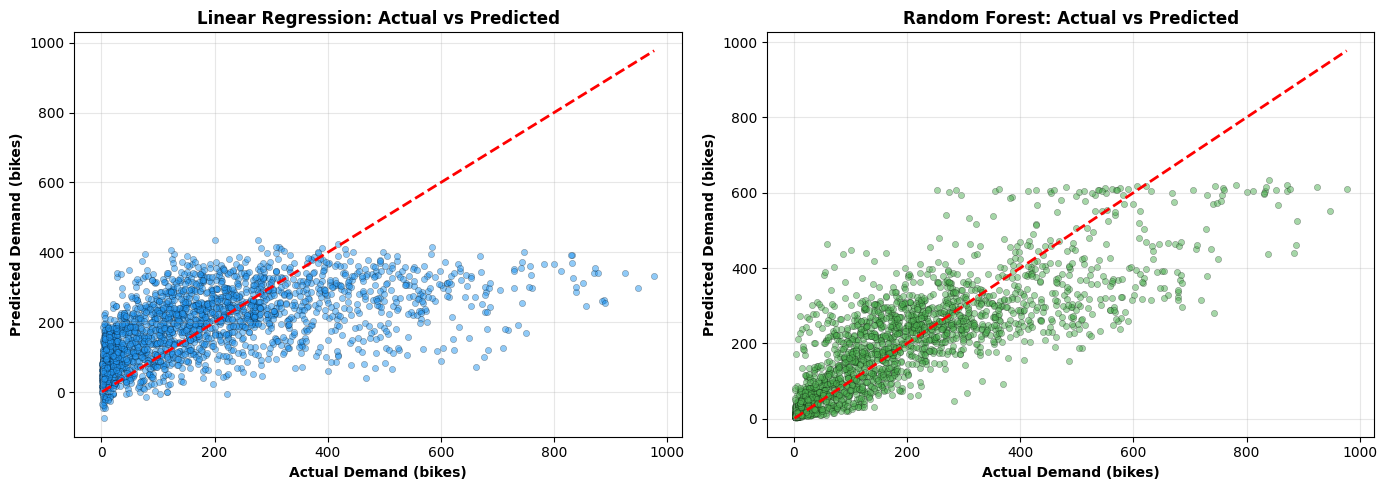

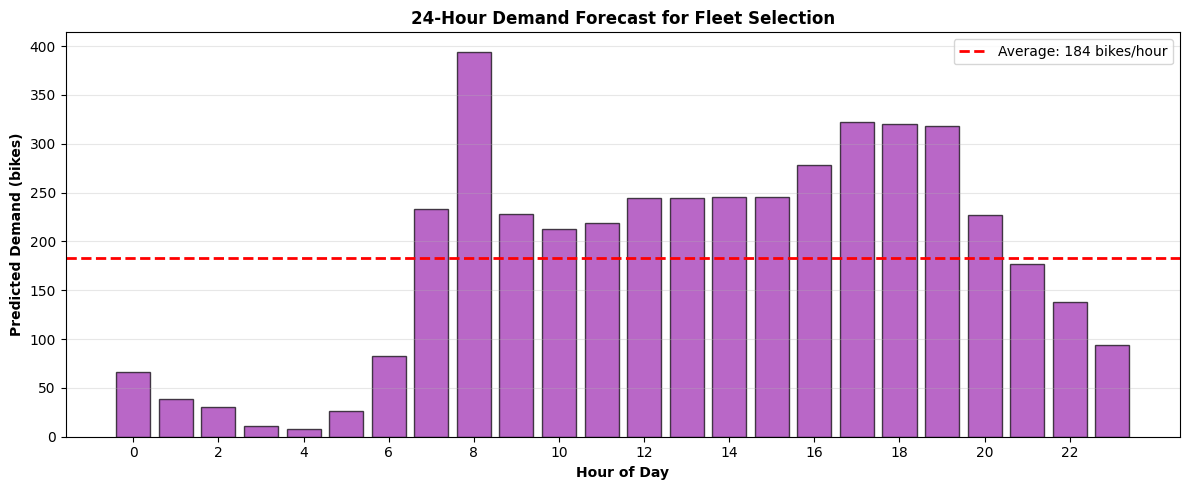

In [4]:
print(f"Step 6 Complete: Predictions exported for Fleet Selector module")


print("\n\nGenerating visualizations...\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['Linear\nRegression', 'Random\nForest']
axes[0].bar(models, [mae_lr, mae_rf], color=['#2196F3', '#4CAF50'], alpha=0.7, edgecolor='black', width=0.6)
axes[0].set_ylabel('MAE (bikes)', fontweight='bold')
axes[0].set_title('Mean Absolute Error Comparison', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([mae_lr, mae_rf]):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

axes[1].bar(models, [rmse_lr, rmse_rf], color=['#FF9800', '#F44336'], alpha=0.7, edgecolor='black', width=0.6)
axes[1].set_ylabel('RMSE (bikes)', fontweight='bold')
axes[1].set_title('Root Mean Squared Error Comparison', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([rmse_lr, rmse_rf]):
    axes[1].text(i, v + 3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, c='#2196F3', s=20, edgecolors='black', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Demand (bikes)', fontweight='bold')
axes[0].set_ylabel('Predicted Demand (bikes)', fontweight='bold')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred_rf, alpha=0.5, c='#4CAF50', s=20, edgecolors='black', linewidth=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Demand (bikes)', fontweight='bold')
axes[1].set_ylabel('Predicted Demand (bikes)', fontweight='bold')
axes[1].set_title('Random Forest: Actual vs Predicted', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/predictions_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(12, 5))

hours = list(range(24))
demands = [hourly_forecast[h]['demand'] for h in hours]

ax.bar(hours, demands, color='#9C27B0', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(demands), color='red', linestyle='--', linewidth=2, label=f'Average: {np.mean(demands):.0f} bikes/hour')
ax.set_xlabel('Hour of Day', fontweight='bold')
ax.set_ylabel('Predicted Demand (bikes)', fontweight='bold')
ax.set_title('24-Hour Demand Forecast for Fleet Selection', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_demand_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
print("DEMAND FORECASTING MODULE")


print(f"ALL STEPS COMPLETED:\n")

print(f"  Selected 5 features: {', '.join(feature_cols)}")
print(f"  Split data: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"  Trained: Linear Regression + Random Forest")
print(f"  Reported MAE and RMSE for both models")
print(f"  Exported predictions for Fleet Selector module")

print(f"MODEL PERFORMANCE:")
print(f"  Best Model: {best_model_name}")
print(f"  MAE:  {best_mae:.2f} bikes/hour")
print(f"  RMSE: {best_rmse:.2f} bikes/hour")

print(f"FORECAST SUMMARY:")
print(f"  Total daily demand: {total_daily_demand:.0f} bikes")
print(f"  Average hourly demand: {total_daily_demand/24:.0f} bikes/hour")
print(f"  Peak hour demand: {max(demands):.0f} bikes/hour")
print(f"  Low hour demand: {min(demands):.0f} bikes/hour")

print(f" OUTPUT FILES CREATED:")
print(f"  - {output_dir}/hourly_demand_forecast.json")
print(f"  - {output_dir}/hourly_demand_forecast.csv")
print(f"  - {output_dir}/model_metrics.json")
print(f"  - {output_dir}/model_comparison.png")
print(f"  - {output_dir}/predictions_comparison.png")
print(f"  - {output_dir}/hourly_demand_forecast.png")



DEMAND FORECASTING MODULE
ALL STEPS COMPLETED:

  Selected 5 features: hour, day, temp, weather, zone_density
  Split data: 8708 train, 2178 test
  Trained: Linear Regression + Random Forest
  Reported MAE and RMSE for both models
  Exported predictions for Fleet Selector module
MODEL PERFORMANCE:
  Best Model: Random Forest
  MAE:  70.67 bikes/hour
  RMSE: 103.73 bikes/hour
FORECAST SUMMARY:
  Total daily demand: 4405 bikes
  Average hourly demand: 184 bikes/hour
  Peak hour demand: 394 bikes/hour
  Low hour demand: 8 bikes/hour
 OUTPUT FILES CREATED:
  - demand_forecast_output/hourly_demand_forecast.json
  - demand_forecast_output/hourly_demand_forecast.csv
  - demand_forecast_output/model_metrics.json
  - demand_forecast_output/model_comparison.png
  - demand_forecast_output/predictions_comparison.png
  - demand_forecast_output/hourly_demand_forecast.png
